# Hypothesis Testing
  * Analyzing Gender-Based Differences in Student Performance
  * Statistical Analysis of Male vs Female Scores Using Hypothesis Testing

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("students_scores.csv")

print("Rows, Columns:", df.shape)

print(df.head())

Rows, Columns: (500, 3)
   Gender      Score Score_Category
0    Male  66.532063         Medium
1  Female  62.851528         Medium
2    Male  70.534850           High
3    Male  83.563988           High
4    Male  77.140937           High


## Summary Statistics by Gender

In [6]:
result = df.groupby("Gender")["Score"].describe()

print(result)

        count       mean       std        min        25%        50%  \
Gender                                                                
Female  256.0  77.863604  9.964107  51.490302  70.866562  78.214643   
Male    244.0  74.902766  9.931352  42.587327  67.969944  74.802926   

              75%    max  
Gender                    
Female  84.640161  100.0  
Male    81.330662  100.0  


## Calculate Average Scores

In [7]:
avg_scores = df.groupby("Gender")["Score"].mean()

print("Average Scores by Gender:\n")

print(avg_scores)

Average Scores by Gender:

Gender
Female    77.863604
Male      74.902766
Name: Score, dtype: float64


## Interpretation of Average Scores

In [8]:
print("Interpretation:")

# Check which group has higher average scores

if avg_scores["Female"] > avg_scores["Male"]:
    print("\n Female students scored higher on average.")
    
elif avg_scores["Male"] > avg_scores["Female"]:
    print("\n Male students scored higher on average.")
    
else:
    print("\n Both genders have the same avg scores.")

Interpretation:

 Female students scored higher on average.


## Visualization - Gender vs Scores

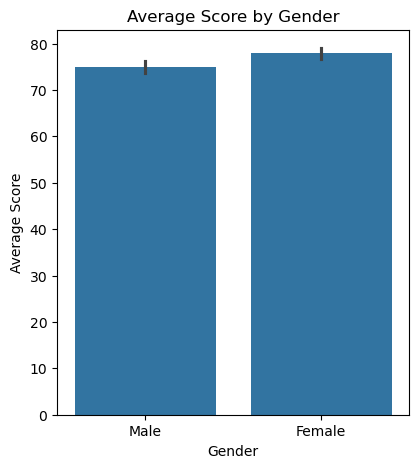

In [9]:
import seaborn as sns

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.barplot(x="Gender", y="Score", data=df) 
plt.title("Average Score by Gender")
plt.ylabel("Average Score")
plt.xlabel("Gender")
plt.show()

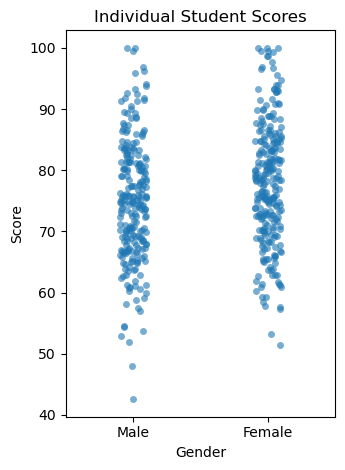

In [10]:
# Shows individual student scores
plt.subplot(1,2,2)
sns.stripplot(x="Gender", y="Score", data=df, jitter=True, alpha = 0.6)
plt.title("Individual Student Scores")
plt.ylabel("Score")
plt.xlabel("Gender")

plt.tight_layout()
plt.show()

## Hypothesis Testing (T-Test): Male vs Female Scores Analysis: Independent
Purpose:
* To check whether the difference in average scores between male and female is REAL or just happened by chance using statistical testing.

# T-Test (Comparing Two Groups)

In [11]:
#Filter scores by gender
male_scores = df[df["Gender"] == "Male"]["Score"]

female_scores = df[df["Gender"] == "Female"]["Score"]

#Perform Independent T-Test
from scipy import stats
t_stats, p_value = stats.ttest_ind(male_scores, female_scores, equal_var= True)
#Compare both groups
#t_stat = difference strength
#p_value = chance probability

print(f"T-statistics: {t_stats:4f}")
print(f"P-Value: {p_value: 6f}")

T-statistics: -3.326616
P-Value:  0.000944


## Output Explanation:
__T-Statistics: -3.326616__
* This shows the difference between male and female averages.
* Negative value means: Female scores are higher than Male scores.
* Larger absolute value ( |3.32| ) = stronger difference.

__P-value: 0.000944__
* This tells the probability that the difference happened by chance.
* Since 0.000944 < 0.05 (significance level), the cutoff to decide if a result is real or just by chance (usually 0.05)

__Final Conclusion__:
* There is a statistically significant difference between male and female scores.
* The difference is REAL, not due to any chance.
* Female students performed better on average.

# Final Interpretation of Hypothesis Test

In [12]:
# Set significance level (alpha)
alpha = 0.05 # If p-value < 0.05 = significant difference

#check condition using p-value
if p_value < alpha:
    conclusion = "We reject H0 - male and female scores are different."
    #Reject Null Hypothesis - difference is real

else:
    conclusion = "We keep H1 - male and female scores are similar."
    # Fail to reject = no strong evidence of difference

# create summary
summary = {
    "T-statistics": round(t_stats, 4),
    "P-Value": round(p_value, 6),
    "Alpha": alpha,
    "Conclusion": conclusion
}

pd.DataFrame([summary])

,T-statistics,P-Value,Alpha,Conclusion
0,-3.3266,0.000944,0.05,We reject H0 - male and female scores are diff...


# Summary Statistics by Gender (Mean, Std, Count)

In [20]:
# Calculate mean
mean_male = male_scores.mean()
mean_female = female_scores.mean()

#Calculate SD
std_male = male_scores.std()
std_female = female_scores.std()

#Count 
n_male = len(male_scores)
n_female = len(female_scores)


#Print Results
print("Summary Statistics by Gender")
print("--------------------------------------------")

print(f"Mean Score (Male): {mean_male:.2f}")
print(f"Mean Score (Female): {mean_female:.2f}")

print(f"Standard Deviation (Male): {std_male:.2f}")
print(f"Standard Deviation (Female): {std_female:.2f}")

print(f"Number of Male students: {n_male}")
print(f"Number of Female students: {n_female}")

Summary Statistics by Gender
--------------------------------------------
Mean Score (Male): 74.90
Mean Score (Female): 77.86
Standard Deviation (Male): 9.93
Standard Deviation (Female): 9.96
Number of Male students: 244
Number of Female students: 256


# Z-Test (Checking Population vs Sample Mean)
It checks whether the average score of all 500 students in your dataset is significantly different from a known population mean (70) assumed population mean (a reference value).

In [24]:
# Z-test (Large Sample, Variance known)
# Z- Statistics : How far the sample mean is from the population mean in std units
# P-value: Probability this difference happened by chance

#Assume population mean and std are known
population_mean = 70
population_std = 10

#Z fromula 
# Sample mean and Size

sample_mean = df["Score"].mean()
n=len(df)

pop_mean = 70
pop_std = 10

#Z-Statistics 
z_stats = (sample_mean - pop_mean) / (pop_std / np.sqrt(n)) # sqrt of sample size n

p_value = 2 * (1 - stats.norm.cdf(abs(z_stats))) # probability in the tail beyound your Z value

print(f"Z-Statistic: {z_stat:.4f}, P-Value: {p_value:.5f}")

# If p-value < 0.5 = the students' average score is really different from 70
# If p_value > 0.5 = the students' average score is not really different from 70

Z-Statistic: 14.3527, P-Value: 0.00000


## Z-Statistic = 14.35
This means your sample mean is 14 standard deviation away from 70 ! This is extremely large : very strong difference.

# F-Test (Comparing Variances - Male vs Female)

It compares the spread (variance) of male and female scores - not the averages, but how consistent or variable their scores are.

Calculate how spread out each group's scores are : variance

Divide the variance : F-Statistics

Check if this difference is significant using p_value

In [27]:
#F-Test Interpretation (Variance: Male vs Female)

# Calculate Variance 
var_male = male_scores.var()
var_female = female_scores.var()

#Calculate F-statistics 
F = var_male /var_female

#Degree of freedom
df1 = len(male_scores) -1
df2 = len(female_scores) -1

#Calculate p_value
p_value = 1 - stats.f.cdf(F, df1, df2)

print(f"F-Statistics : {F: .5f}, P-Value: {p_value: .5f}")

#Output Explanation:
  # F-Statistics: 0.99344: very close to 1, variances are almost equal
  # P-value: 0.52029: greater than 0.05, high probability (chance)

#Final Conclusion:
    #Fail to reject H0
    # Male and female students have similar variability (spread)
    # No significant difference in variance

F-Statistics :  0.99344, P-Value:  0.52029
